# 1. Build and fit your first model: the two-armed bandit

> **Level** Beginner · **Time** 30 minutes · **Prerequisites** the [quickstart](../get-started/quickstart.ipynb), and some familiarity with reinforcement learning ·
> **cpm components** [`Parameters`](#cpm.generators.Parameters), [`Value`](#cpm.generators.Value), [`Wrapper`](#cpm.generators.Wrapper), [`Simulator`](#cpm.generators.Simulator), [`Softmax`](#cpm.models.decision.Softmax), [`SeparableRule`](#cpm.models.learning.SeparableRule), [`FminBound`](#cpm.optimisation.FminBound) ·
> **Data** [`load_bandit_data`](#cpm.datasets.load_bandit_data)

In this tutorial, we build a reinforcement learning model of a two-armed bandit task from cpm components, fit it to the choices of 200 participants, and simulate new choices from the fitted parameters.

**What you'll learn**

- how to describe the parameters of a model, with bounds and priors,
- how to write the computations of a single trial as a model function,
- how a [`Wrapper`](#cpm.generators.Wrapper) runs that function over the trials of one participant,
- how to fit the model to every participant with [`FminBound`](#cpm.optimisation.FminBound),
- how to simulate new choices from the fitted parameters with a [`Simulator`](#cpm.generators.Simulator).

In [1]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)
np.random.seed(2026)

0.25.7.dev0


## The two-armed bandit task

The two-armed bandit is a two-alternative forced-choice reinforcement learning problem, part of the larger family of multi-armed bandit problems.
On each trial, the participant chooses between two options, and each option pays out a reward with a different probability.
The participant does not know these probabilities, and has to learn which option is best from the rewards they receive.

In our version of the task, there are four stimuli, and two of them are shown on each trial, one on the left and one on the right.
For example, if stimulus 1 gives a reward with a probability of 0.7, you can expect to be rewarded on 70% of the trials in which you choose stimulus 1.

## The data

cpm ships with data from 200 participants who completed this task.

In [2]:
from cpm.datasets import load_bandit_data

experiment = load_bandit_data()
experiment.head(10)

,ppt,trial,arm_left,arm_right,reward_left,reward_right,response,feedback
0,1,1,2,1,0.0,1.0,1,1.0
1,1,2,3,2,1.0,0.0,0,1.0
2,1,3,1,3,1.0,0.0,0,1.0
3,1,4,1,3,0.0,0.0,0,0.0
4,1,5,2,4,1.0,0.0,0,1.0
5,1,6,3,1,1.0,1.0,0,1.0
6,1,7,4,2,1.0,1.0,1,1.0
7,1,8,1,4,0.0,0.0,0,0.0
8,1,9,3,4,0.0,0.0,0,0.0
9,1,10,1,4,1.0,0.0,0,1.0


The columns are:

- `ppt`: the participant number,
- `trial`: the trial number,
- `arm_left`, `arm_right`: the stimulus (1 to 4) shown on the left and on the right,
- `reward_left`, `reward_right`: the reward the participant would receive for choosing the left or the right stimulus,
- `response`: the choice of the participant (0 for left, 1 for right),
- `feedback`: the reward the participant received.

cpm fits models to a column called `observed`, which holds the behaviour the model should predict.
Here, that is the choice of the participant.

In [3]:
experiment["observed"] = experiment["response"]
print(f"{experiment.ppt.nunique()} participants, {experiment.groupby('ppt').size().mean():.0f} trials each")

200 participants, 72 trials each


## The model

Each stimulus has a value, which is the reward the participant expects to receive when they choose it.
Let $Q(a)$ be the estimated value of action $a$.
On each trial $t$, two stimuli are shown, so $Q(a)$ is either $Q(\text{left})$ or $Q(\text{right})$: the value of the stimulus shown on the left or on the right.

The Softmax choice rule (Bridle, 1990) converts the two values into the probability of choosing each action:

$$
P(a_t) = \frac{e^{\beta Q_t(a)}}{\sum_{i = 1}^{k}{e^{\beta Q_t(i)}}}
$$

where $\beta$ is the inverse temperature, which sets how deterministic the choices are, and $k = 2$ is the number of actions available.

After the choice, the value of the chosen stimulus is updated with the delta rule (Rescorla & Wagner, 1972), in the form used for bandit problems where each option is a single stimulus (Sutton & Barto, 2018):

$$
\Delta Q_t(a_t) = \alpha \left[ R_t - Q_t(a_t) \right]
$$

where $\alpha$ is the learning rate, $R_t$ is the reward received on trial $t$, and $R_t - Q_t(a_t)$ is the prediction error.
The values of the stimuli that were not chosen do not change.

## Building the model

### Parameters

The parameters of a model are described with [`Parameters`](#cpm.generators.Parameters).
Each parameter that should be estimated from the data is a [`Value`](#cpm.generators.Value) with a starting value, lower and upper bounds, and a prior.
Everything without a prior is a fixed part of the model: here, the starting values of the four stimuli.

In [4]:
from cpm.generators import Parameters, Value

parameters = Parameters(
    alpha=Value(
        value=0.5,
        lower=1e-10,
        upper=1,
        prior="truncated_normal",
        args={"mean": 0.5, "sd": 0.25},
    ),
    temperature=Value(
        value=1,
        lower=0,
        upper=10,
        prior="truncated_normal",
        args={"mean": 5, "sd": 2.5},
    ),
    values=np.array([0.25, 0.25, 0.25, 0.25]),
)
parameters.free()

['alpha', 'temperature']

`alpha` and `temperature` have priors, so they are the free parameters that we will estimate, as [`free()`](#cpm.generators.Parameters.free) shows.
**Every free parameter must have a prior.**
The starting value of every stimulus, `values`, is fixed at 0.25.

### The model function

A model in cpm is a function that describes **what happens on a single trial**.
It takes two arguments: the parameters, and the data of the current trial as a `pandas.Series` (one row of the data).
It returns a dictionary with everything we want to keep from that trial.

We use two cpm components: [`Softmax`](#cpm.models.decision.Softmax) for the choice rule, and [`SeparableRule`](#cpm.models.learning.SeparableRule) for the delta rule.
The `generate` argument decides whose choice the model learns from: the choice of the participant when we fit the model, or its own choice when we simulate new data.

In [5]:
from cpm.models.decision import Softmax
from cpm.models.learning import SeparableRule


def model(parameters, trial, generate=False):
    alpha = parameters.alpha
    temperature = parameters.temperature
    values = np.asarray(parameters.values).copy()

    # the stimuli on screen, and the reward each of them would give
    stimuli = np.array([trial.arm_left, trial.arm_right]).astype(int)
    rewards = np.array([trial.reward_left, trial.reward_right])

    # Equation 1: choice probabilities from the values of the two stimuli
    # (stimuli are numbered from 1, Python counts from 0)
    choice_rule = Softmax(activations=values[stimuli - 1], temperature=temperature)
    choice_rule.compute()

    # learn from the choice of the participant, or from the model's own choice
    choice = choice_rule.choice() if generate else int(trial.response)
    reward = rewards[choice]

    # Equation 2: update the value of the chosen stimulus
    chosen = np.zeros(4)
    chosen[stimuli[choice] - 1] = 1
    update = SeparableRule(weights=values, feedback=[reward], input=chosen, alpha=alpha)
    update.compute()
    values += update.weights.flatten()

    return {
        "policy": choice_rule.policies,  # probability of choosing left and right
        "response": choice,  # the choice the model learned from
        "reward": reward,
        "error": update.error[0, stimuli[choice] - 1],  # the prediction error
        "values": values,  # the updated values, used on the next trial
        "dependent": np.array([choice_rule.policies[1]]),  # what the model is fitted to
    }

Two keys of the output are special:

- `values` has the same name as a parameter, so cpm carries its updated value over to the next trial,
- `dependent` is what the model predicts: here, the probability of choosing the stimulus on the right, which is compared with `observed` when we fit the model.

## Running the model for one participant

A [`Wrapper`](#cpm.generators.Wrapper) runs the model function over all trials of a single participant.

In [6]:
from cpm.generators import Wrapper

wrapper = Wrapper(model=model, parameters=parameters, data=experiment[experiment.ppt == 1])
wrapper.run()
wrapper.export().tail()

,policy_0,policy_1,response,reward,error,values_0,values_1,values_2,values_3,dependent,ppt
66,0.658404,0.341596,0,1.0,0.093811,0.953094,0.800049,0.086842,0.250,0.341596,0
67,0.461813,0.538187,1,1.0,0.046906,0.976547,0.800049,0.086842,0.250,0.538187,0
68,0.671109,0.328891,0,0.0,-0.800049,0.976547,0.400024,0.086842,0.250,0.328891,0
69,0.708829,0.291171,0,1.0,0.023453,0.988274,0.400024,0.086842,0.250,0.291171,0
70,0.540699,0.459301,0,1.0,0.750000,0.988274,0.400024,0.086842,0.625,0.459301,0


The exported output has one row per trial, and one column per element of each output, such as `policy_0` and `policy_1` for the probabilities of choosing left and right, or `values_0` to `values_3` for the values of the four stimuli.

## Fitting the model to data

[`FminBound`](#cpm.optimisation.FminBound) estimates the free parameters of each participant, within their bounds.
It minimises the negative log-likelihood of the observed choices ([`LogLikelihood.bernoulli`](#cpm.optimisation.minimise.LogLikelihood)), and with `prior=True` it also adds the log prior probability of the parameters, so that the estimates are maximum *a posteriori*.
We start the optimisation from three random points for each participant, to reduce the risk of ending up in a local minimum.

In [7]:
from cpm.optimisation import FminBound, minimise

fit = FminBound(
    model=wrapper,
    data=experiment.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=True,
    number_of_starts=3,
    ppt_identifier="ppt",
    parallel=False,
    display=False,
    # passed on to scipy.optimize.fmin_l_bfgs_b
    approx_grad=True,
)
fit.optimise()

The results have one row per participant.
`x_0` and `x_1` are the estimates of the free parameters, in the order in which they were defined (`alpha`, then `temperature`), and `fun` is the value of the objective function at the estimates: here, the negative log posterior.
To fit many participants faster, see the how-to guide on [parallel fitting](../how-to/parallelise-fitting.md).

In [8]:
optimisation = fit.export()
optimisation[["ppt", "x_0", "x_1", "fun", "log_likelihood", "log_prior"]].head()

,ppt,x_0,x_1,fun,log_likelihood,log_prior
0,1,0.352648,9.230892,19.124250,-16.243775,-2.880475
1,2,0.241423,2.253127,49.902639,-47.489379,-2.413260
2,3,0.453396,2.236194,46.408787,-44.505584,-1.903203
3,4,0.689269,6.363270,29.040718,-27.330719,-1.709999
4,5,0.388322,5.253324,32.013601,-30.633954,-1.379646


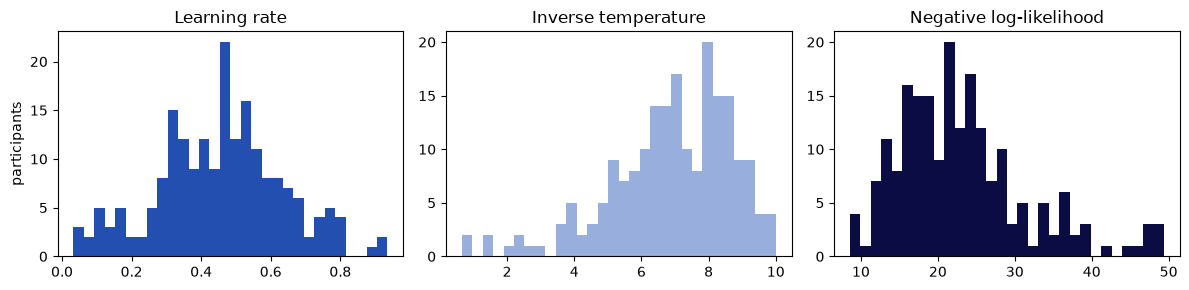

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(optimisation.x_0, bins=30, color="#2350b0")
axes[0].set_title("Learning rate")
axes[1].hist(optimisation.x_1, bins=30, color="#98aedd")
axes[1].set_title("Inverse temperature")
axes[2].hist(-optimisation.log_likelihood, bins=30, color="#0c0c45")
axes[2].set_title("Negative log-likelihood")
axes[0].set_ylabel("participants")
plt.tight_layout()
plt.show()

## Simulating new choices

With the fitted parameters, we can simulate how each participant would behave according to the model.
We wrap the model again, this time with `generate=True`, so that the model learns from its own choices.
The [`Simulator`](#cpm.generators.Simulator) runs this model for every participant, each with their own fitted parameters, which are available as `fit.parameters`.

In [10]:
from functools import partial

from cpm.generators import Simulator

generative = Wrapper(
    model=partial(model, generate=True),
    parameters=parameters,
    data=experiment[experiment.ppt == 1],
)
simulator = Simulator(
    wrapper=generative,
    parameters=fit.parameters,
    data=experiment.groupby("ppt"),
)
simulator.run()
simulation = simulator.export()
simulation[["ppt", "response", "reward", "error", "policy_0", "policy_1"]].head()

,ppt,response,reward,error,policy_0,policy_1
0,1,0,0.0,-0.250000,0.500000,0.500000
1,1,1,0.0,-0.161838,0.692921,0.307079
2,1,1,0.0,-0.250000,0.500000,0.500000
3,1,1,0.0,-0.161838,0.692921,0.307079
4,1,1,0.0,-0.250000,0.207405,0.792595


Did the model learn the task like the participants did?
For each trial, we check whether the stimulus with the higher average reward was chosen, both by the participants and by the simulated agents.

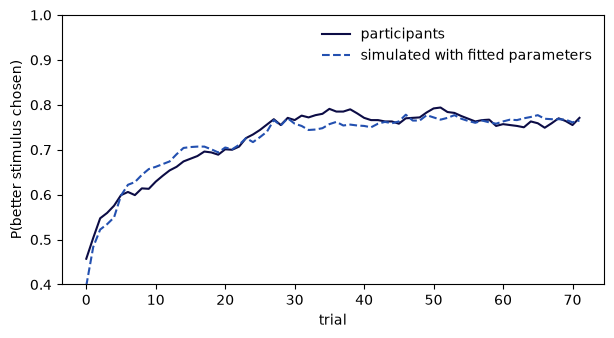

In [11]:
# the average reward of each stimulus, across all trials
payout = pd.concat(
    [
        experiment[["arm_left", "reward_left"]].set_axis(["stimulus", "reward"], axis=1),
        experiment[["arm_right", "reward_right"]].set_axis(["stimulus", "reward"], axis=1),
    ]
).groupby("stimulus")["reward"].mean()

better = np.where(
    payout[experiment.arm_right].to_numpy() > payout[experiment.arm_left].to_numpy(), 1, 0
)
comparison = pd.DataFrame(
    {
        "trial": experiment.trial.to_numpy(),
        "participants": (experiment.response.to_numpy() == better),
        "model": (simulation.response.to_numpy() == better),
    }
).groupby("trial").mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(comparison.index, comparison.participants.rolling(5, min_periods=1).mean(), label="participants", color="#0c0c45")
ax.plot(comparison.index, comparison.model.rolling(5, min_periods=1).mean(), label="simulated with fitted parameters", color="#2350b0", linestyle="--")
ax.set_xlabel("trial")
ax.set_ylabel("P(better stimulus chosen)")
ax.set_ylim(0.4, 1)
ax.legend(frameon=False)
plt.show()

The simulated agents learn to choose the better stimulus at a rate similar to the participants, so the model captures the main pattern of learning in this task.

## Summary and next steps

You built a reinforcement learning model from cpm components, fitted it to 200 participants, and simulated new choices from the fitted parameters.
The same pattern applies to any model: describe the parameters, write the computations of one trial, wrap them, and fit.

This model is also available ready-made as [`RLRW`](#cpm.applications.reinforcement_learning.RLRW), which is what the [quickstart](../get-started/quickstart.ipynb) uses.
If your data are in a different format, [`convert_to_RLRW`](#cpm.utils.data.convert_to_RLRW) converts them into the columns that `RLRW` expects.

Before interpreting the estimates, we should check that they can be trusted.
That is the topic of the next tutorial: [2. Parameter recovery](parameter-recovery.ipynb).

## References

Bridle, J. S. (1990). Probabilistic interpretation of feedforward classification network outputs, with relationships to statistical pattern recognition. In F. F. Soulié & J. Hérault (Eds.), *Neurocomputing* (pp. 227–236). Springer.

Rescorla, R. A., & Wagner, A. R. (1972). A theory of Pavlovian conditioning: Variations in the effectiveness of reinforcement and nonreinforcement. In A. H. Black & W. F. Prokasy (Eds.), *Classical conditioning II: Current research and theory* (pp. 64–99). Appleton-Century-Crofts.

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press.